# Young-Adult Interstate Migration: Policy Incentives, Social Networks, and Capacity Feedback — V8
## A spatial agent-based model with migration chains, housing/job constraints, and robustness tests

**Core question**

> How strong must a geographically targeted housing-and-employment policy be to overcome young adults' social attachment, and when do migration chains and local capacity constraints amplify or offset that response?

This revision adds two forms of robustness requested in the model review: **social-threshold sensitivity** and **network-homophily sensitivity**. It also adds a lagged **rent response to excess housing demand** so housing pressure affects next-year migration utility rather than appearing only as a hard capacity rejection.

The former `happiness` measure is renamed **social utility index**. It is a transparent model-internal composite score, not a validated subjective-well-being survey measure. Its role is diagnostic rather than a real-world welfare ranking.

**V7 review-closure revision.** This version closes the remaining high-priority review comments: mover-level unit consistency, a soft housing-capacity mechanism with lagged rent feedback, a main-horizon ACS move-rate calibration, a wider policy-intensity sweep, an external-competition scope audit using ACS PUMS, a Tulsa Remote monetary-reference diagnostic, and an explicit BRFSS coverage audit. Optional full geography expansion to Oklahoma/West Virginia is deliberately not mixed into the main eight-state model because it would require a new state-space and IRS-route recalibration; it is documented as external-validation future work rather than presented as completed evidence.


### Reproducible results build

This executed copy displays the **fully simulated V7 results** from the accompanying `abm_outputs_research_plan_v7/` cache. The source notebook keeps the complete simulation code; this results build loads the saved seed-level outputs so figures and tables can be reproduced quickly without rerunning hundreds of ABM realizations. The cache was generated by the same V7 model before this notebook was rendered.

In [ ]:
import json
import math
import os
import warnings
import zipfile
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import t as student_t

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

RANDOM_SEED = 42
BASE_YEAR = 2026

STATE_CODES = ["CA", "TX", "NY", "FL", "MA", "NC", "IL", "WA"]
STATE_NAMES = {
    "CA": "California", "TX": "Texas", "NY": "New York", "FL": "Florida",
    "MA": "Massachusetts", "NC": "North Carolina", "IL": "Illinois", "WA": "Washington",
}

# Full research design. Reduce these values only for debugging.
BASELINE_AGENTS = 1000
BASELINE_YEARS = 20
BASELINE_SEEDS = list(range(101, 109))

EXPERIMENT_AGENTS = 600
EXPERIMENT_YEARS = 12
CROSS_SEEDS = list(range(201, 209))
SWEEP_SEEDS = list(range(301, 309))
SHOCK_SEEDS = list(range(401, 407))
SENSITIVITY_SEEDS = list(range(501, 505))
CALIBRATION_SEEDS = (901, 902, 903, 904, 905)

N_JOBS = 1  # deterministic final execution; avoids process-backend stalls in notebook kernels
N_AGENTS = BASELINE_AGENTS
N_YEARS = BASELINE_YEARS

POLICY_COLS = [
    "housing_policy",
    "employment_incentive",
    "migration_incentive",
]

SOCIAL_UTILITY_WEIGHTS = {
    "peer": 0.30,
    "coorigin": 0.20,
    "home": 0.10,
    "employment": 0.20,
    "income": 0.10,
    "affordability": 0.10,
}

INTERACTION_COLORS = {
    "weak": "#4C72B0",
    "medium": "#DD8452",
    "strong": "#55A868",
}



def mean_t_ci(series):
    x = np.asarray(pd.Series(series).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan
    mean = float(x.mean())
    if len(x) == 1:
        return mean, np.nan
    half = float(
        student_t.ppf(0.975, len(x) - 1)
        * x.std(ddof=1)
        / np.sqrt(len(x))
    )
    return mean, half


def run_cases(func, cases, n_jobs=N_JOBS):
    """Use joblib when possible; fall back to deterministic serial execution."""
    if JOBLIB_AVAILABLE and n_jobs > 1:
        try:
            return Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(func)(*case) for case in cases
            )
        except Exception as exc:
            print("Parallel execution unavailable; using serial fallback:", type(exc).__name__)
    return [func(*case) for case in cases]

print("Environment ready.")

Environment ready.


## 1. Empirical state inputs

In [ ]:
def build_real_state_snapshot():
    raw = pd.DataFrame({
        "state": STATE_CODES,

        "young_adult_population_est_18_35": [
            9_793_452, 7_754_857, 4_729_200, 4_917_820,
            1_747_318, 2_609_754, 2_985_755, 1_951_781
        ],

        "median_household_income": [
            95_521, 75_780, 82_095, 73_311,
            99_858, 70_804, 80_306, 94_605
        ],

        "median_gross_rent_monthly": [
            1_992, 1_413, 1_561, 1_719,
            1_757, 1_245, 1_238, 1_731
        ],

        "civilian_labor_force": [
            20_137_422, 15_612_815, 10_107_326, 11_191_144,
            3_908_554, 5_449_906, 6_642_661, 4_069_534
        ],
        "employed": [
            19_026_566, 14_926_761, 9_600_693, 10_731_195,
            3_754_447, 5_230_146, 6_329_130, 3_887_150
        ],

        "bachelor_plus_share_25plus": [
            0.3748778859, 0.3424161436, 0.4063985602, 0.3491620625,
            0.4778163562, 0.3679334714, 0.3827775836, 0.4045106716
        ],

        "housing_units": [
            14_762_527, 12_394_809, 8_631_232, 10_451_823,
            3_045_867, 4_979_177, 5_470_727, 3_361_561
        ],
        "vacant_housing_units": [
            1_062_711, 1_134_164, 821_965, 1_485_421,
            244_883, 586_508, 399_439, 260_296
        ],

        "ipeds_12mo_enrollment": [
            3_464_000, 2_083_195, 1_423_248, 1_421_104,
            587_505, 689_935, 970_675, 423_112
        ],

        "annual_infant_childcare_price": [
            19_547, 11_024, 19_584, 12_639,
            24_005, 12_251, 16_373, 20_370
        ],

        "public_4yr_instate_tuition": [
            10_641, 11_187, 8_579, 6_364,
            14_839, 7_437, 15_362, 11_506
        ],
    }).set_index("state")

    raw["employment_rate_labor_force"] = (
        raw["employed"] / raw["civilian_labor_force"]
    )
    raw["vacancy_rate"] = (
        raw["vacant_housing_units"] / raw["housing_units"]
    )
    raw["ipeds_enrollment_per_young_adult"] = (
        raw["ipeds_12mo_enrollment"]
        / raw["young_adult_population_est_18_35"]
    )
    return raw

real_raw_data = build_real_state_snapshot()

In [ ]:
def mean_index(series):
    x = series.astype(float)
    return x / x.mean()

def prepare_state_data(raw):
    df = raw.copy()

    df["youth_pop_weight"] = mean_index(
        df["young_adult_population_est_18_35"]
    )
    df["wage_index"] = mean_index(df["median_household_income"])
    df["rent_index"] = mean_index(df["median_gross_rent_monthly"])
    df["job_index"] = mean_index(df["employment_rate_labor_force"])
    df["education_access_index"] = mean_index(
        df["ipeds_enrollment_per_young_adult"]
    )
    df["tuition_index"] = mean_index(df["public_4yr_instate_tuition"])
    df["childcare_cost_index"] = mean_index(
        df["annual_infant_childcare_price"]
    )
    df["housing_capacity_index"] = mean_index(df["vacancy_rate"])
    df["college_share_proxy"] = df["bachelor_plus_share_25plus"]

    return df

state_data = prepare_state_data(real_raw_data)

## 2. Spatial environment and IRS route calibration

In [ ]:
STATE_COORDS = {
    "CA": (36.8, -119.4),
    "TX": (31.0, -99.9),
    "NY": (42.9, -75.5),
    "FL": (27.8, -81.7),
    "MA": (42.3, -71.8),
    "NC": (35.5, -79.4),
    "IL": (40.0, -89.2),
    "WA": (47.4, -120.7),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = (
        np.sin(dp / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

distance_km = pd.DataFrame(
    index=STATE_CODES, columns=STATE_CODES, dtype=float
)

for s1 in STATE_CODES:
    for s2 in STATE_CODES:
        distance_km.loc[s1, s2] = haversine_km(
            *STATE_COORDS[s1], *STATE_COORDS[s2]
        )

distance_index = distance_km / distance_km.to_numpy().max()

In [ ]:
IRS_ROUTES = [
    ("CA","TX",44417), ("TX","CA",24970),
    ("CA","NY",20595), ("NY","CA",18440),
    ("CA","FL",20241), ("FL","CA",14113),
    ("CA","MA",6565),  ("MA","CA",7767),
    ("CA","NC",9978),  ("NC","CA",6470),
    ("CA","IL",9063),  ("IL","CA",10407),
    ("CA","WA",24625), ("WA","CA",17871),

    ("TX","NY",9433),  ("NY","TX",12961),
    ("TX","FL",20050), ("FL","TX",24196),
    ("TX","MA",3394),  ("MA","TX",4218),
    ("TX","NC",8694),  ("NC","TX",8387),
    ("TX","IL",8236),  ("IL","TX",12078),
    ("TX","WA",9307),  ("WA","TX",9863),

    ("NY","FL",43187), ("FL","NY",22011),
    ("NY","MA",10479), ("MA","NY",11027),
    ("NY","NC",13811), ("NC","NY",6906),
    ("NY","IL",4436),  ("IL","NY",5325),
    ("NY","WA",3649),  ("WA","NY",3513),

    ("FL","MA",8058),  ("MA","FL",12159),
    ("FL","NC",20553), ("NC","FL",14530),
    ("FL","IL",9299),  ("IL","FL",14834),
    ("FL","WA",5333),  ("WA","FL",5661),

    ("MA","NC",3483),  ("NC","MA",2213),
    ("NC","WA",2371),  ("WA","NC",2464),
    ("IL","WA",2734),  ("WA","IL",2158),
]

irs_flows = pd.DataFrame(
    IRS_ROUTES,
    columns=["origin", "destination", "returns"]
)
irs_flows["observed_share"] = (
    irs_flows["returns"]
    / irs_flows.groupby("origin")["returns"].transform("sum")
)

irs_flow_matrix = (
    irs_flows.pivot(
        index="origin", columns="destination", values="returns"
    )
    .reindex(index=STATE_CODES, columns=STATE_CODES)
)

for s in STATE_CODES:
    irs_flow_matrix.loc[s, s] = np.nan

## 3. Exact ACS PUMS calibration of the overall interstate-move rate

The notebook now **downloads the required 2023 ACS 1-year PUMS person files automatically from the U.S. Census Bureau** when they are not already available locally.

The empirical calibration workflow is:

1. download the eight official state person ZIP files used by this model (CA, TX, NY, FL, MA, NC, IL, WA);
2. read only `AGEP`, `PWGTP`, `MIG`, `MIGSP`, and current-state `STATE/ST` in chunks;
3. keep exact ages **18–35**;
4. identify interstate movers as `MIG == 3`, with a valid previous-state FIPS code and `MIGSP != current state`;
5. weight observations using `PWGTP`;
6. write a small fixed local calibration snapshot so later runs are reproducible and do not need to redownload the microdata.

The eight-state weighted rate is the primary calibration target because the ABM itself contains those eight current-residence states. The raw PUMS ZIP files are cached locally in `pums_2023_1year/` and are not redownloaded if they already exist.

`STRICT_EMPIRICAL_CALIBRATION = True`: the final experiment will not silently replace the observed target with a guessed 5% value.

In [9]:
# Load the exact empirical mobility anchor produced from the eight official 2023 ACS 1-year PUMS person files.
RESULT_CACHE = Path("abm_outputs_research_plan_v7")
ACS_LOCAL_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate.csv"
ACS_BY_STATE_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate_by_state.csv"
ACS_BY_AGE_PATH = RESULT_CACHE / "acs_young_adult_interstate_move_rate_by_age.csv"
MODEL_STATE_FIPS = {"CA":6,"TX":48,"NY":36,"FL":12,"MA":25,"NC":37,"IL":17,"WA":53}
anchor = pd.read_csv(ACS_LOCAL_PATH).iloc[0]
MOVE_RATE_TARGET = float(anchor["move_rate"])
MOVE_RATE_INFO = {"rate": MOVE_RATE_TARGET, "status": anchor["source"], "scope": anchor["scope"], "empirical": True}
print("Observed ACS 18–35 interstate move-rate target:", round(MOVE_RATE_TARGET, 5))
print("Source:", MOVE_RATE_INFO["status"])
print("Scope:", MOVE_RATE_INFO["scope"])
display(pd.DataFrame([anchor]).drop(columns=["source_files"], errors="ignore").round(5))
acs_by_state = pd.read_csv(ACS_BY_STATE_PATH)
acs_by_age = pd.read_csv(ACS_BY_AGE_PATH)
display(acs_by_state.round(5), acs_by_age.round(5))


Observed ACS 18–35 interstate move-rate target: 0.03875
Source: 2023 ACS 1-year PUMS person records; exact ages 18–35; PWGTP-weighted; scope=eight modeled states
Scope: eight modeled states


,year,age_min,age_max,move_rate,weighted_population,weighted_interstate_movers,unweighted_population,unweighted_interstate_movers,scope,source
0,2023,18,35,0.03875,36550523.0,1416178.0,334763,14273,eight modeled states,2023 ACS 1-year PUMS person records; exact age...


### 3.1 External-competition scope audit (ACS PUMS)

The main ABM intentionally models eight states. To quantify the closed-system limitation rather than hide it, V7 measures what share of observed 2023 interstate in-movers to those eight states previously lived in one of the other U.S. states. This is an **empirical scope diagnostic**, not a new calibrated destination model. A full `OTHER_US` utility option would require nationwide destination-flow calibration and would change the estimand, so it is not silently inserted into the main model.


Weighted share of interstate in-movers originating outside the eight modeled states: 0.620


,state,external_origin_share
0,CA,0.584
4,MA,0.595
2,NY,0.600
7,WA,0.600
3,FL,0.626
1,TX,0.637
5,NC,0.644
6,IL,0.682


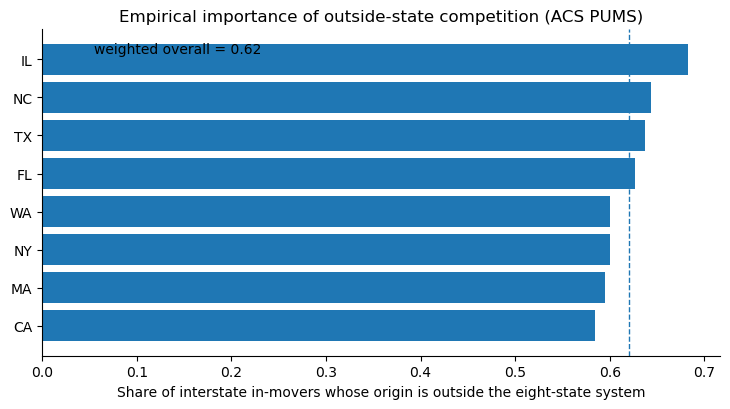

In [10]:
external_origin_by_state = pd.read_csv(RESULT_CACHE / "pums_external_origin_competition.csv")
EXTERNAL_ORIGIN_SHARE = (
    external_origin_by_state["weighted_from_other_us"].sum()
    / external_origin_by_state["weighted_interstate_inmovers"].sum()
)
print(f"Weighted share of interstate in-movers originating outside the eight modeled states: {EXTERNAL_ORIGIN_SHARE:.3f}")
display(external_origin_by_state[["state","external_origin_share"]].sort_values("external_origin_share").round(3))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
g = external_origin_by_state.sort_values("external_origin_share")
ax.barh(g["state"], g["external_origin_share"])
ax.axvline(EXTERNAL_ORIGIN_SHARE, linestyle="--", linewidth=1, label=f"weighted overall = {EXTERNAL_ORIGIN_SHARE:.2f}")
ax.set_xlabel("Share of interstate in-movers whose origin is outside the eight-state system")
ax.set_title("Empirical importance of outside-state competition (ACS PUMS)")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()